In [4]:
!pip install pandas --quiet
import pandas as pd
df= pd.read_csv("agriculture_yield_dataset.csv")

In [9]:
#Part A: Understanding the Dataset

#Q1: Dataset overview
#Load the dataset and answer the following:

#1.How many rows and columns are present?
print('(rows,columns) are respectively given as:','\n',df.shape)
print(' rows are: ',df.shape[0])
print(' columns are: ',df.shape[1])

#2.What are the names of all the columns?
print('names of all columns are: ',df.columns)

#3.Display the first 10 records.
print('first 10 records are:','\n',df.head(10))

(rows,columns) are respectively given as: 
 (1500, 8)
 rows are:  1500
 columns are:  8
names of all columns are:  Index(['rainfall_mm', 'temperature_c', 'fertilizer_kg', 'irrigation_hours',
       'soil_ph', 'crop_type', 'soil_type', 'yield_ton_per_hectare'],
      dtype='object')
first 10 records are: 
    rainfall_mm  temperature_c  fertilizer_kg  irrigation_hours  soil_ph  \
0        588.6           18.6          242.4               6.5      6.5   
1        772.8           34.6          247.2              10.0      6.5   
2        970.9           36.3          168.4               7.3      6.4   
3        611.7           19.0          121.7               3.7      6.0   
4        696.1           29.6          184.6               5.1      6.1   
5        831.9           28.0          190.3               2.1      6.1   
6       1023.8           32.0          108.5               6.9      6.2   
7       1142.4           18.4          241.9               4.1      7.3   
8        810.4    

In [14]:
#Q2: Data Types and Missing Values.
#1.Checks data type of every column.
print('Data Type of the column:')
print(df.dtypes)

#2.checks if missing values are present or not
print('\nMissing values present in column:')
print(df.isnull().sum())

#3.If missing values exist, mention affected columns.
print('\nColumns with missing values are:')
print(df.columns[df.isnull().any()])

Data Type of the column:
rainfall_mm              float64
temperature_c            float64
fertilizer_kg            float64
irrigation_hours         float64
soil_ph                  float64
crop_type                 object
soil_type                 object
yield_ton_per_hectare    float64
dtype: object

Missing values present in column:
rainfall_mm              0
temperature_c            0
fertilizer_kg            0
irrigation_hours         0
soil_ph                  0
crop_type                0
soil_type                0
yield_ton_per_hectare    0
dtype: int64

Columns with missing values are:
Index([], dtype='object')


In [16]:
#Q3:Descriptive Statictics.
#create summary statistics for the numerical features and answer:

#1.Feature with highest mean value
means = df.mean(numeric_only=True)
highest_mean_feature = means.idxmax()
print(highest_mean_feature," is feature with highest mean value")

#2.Feature with the highest standard deviation?
stds = df.std(numeric_only=True)
highest_std_feature = stds.idxmax()
print(highest_std_feature," is feature with highest standard deviation")

rainfall_mm  is feature with highest mean value
rainfall_mm  is feature with highest standard deviation


In [20]:
!pip install plotly matplotlib seaborn --quiet
import plotly.express as px
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [24]:
#Part B: Exploratory data Analysis
#Q4:Create histograms for:
#Write 2-3 observations for each histogram
#for that we need to find the maximum and minimum value of the column


#1.rainfall_mm
df.rainfall_mm.describe()
#max is 1200 and min is 300.200, thus it can be shown in 902 bins of a histogram
fig = px.histogram(df,x='rainfall_mm',marginal='box',nbins=902,title='Rainfall analysis')
fig.update_layout(bargap=0.1)
fig.show()

#observations:
#rainfall value ranges from approximately 300mm to 1200 mm, indicating high variability.
#The median is 761.2mm with half of the observations lying roughly between 500 mm and 950mm,
#It does not show any major outlier, suggesting rainfall values are spread fairly uniformly across the range.


#2.temperature_c
df.temperature_c.describe()
#max is 38 and min is 18 so it can be shown in 21 bins of a histogram
fig = px.histogram(df,x='temperature_c',marginal='box',nbins=21,title='Temperature analysis')
fig.update_layout(bargap=0.1)
fig.show()

#observations:
#The temperature values range approximately from 18 degree to 38 degree celcius, showing a wide variation.
#Most temperature readings are concentrated between 23 to 33 degree celcius with a median of 27.7.
#The box plot shows no significant outliers.


#3.fertilizer_kg
df.fertilizer_kg.describe()
#max is 249.90 and min is 50.30 thus it can be shown in 201 bins of a histogram
fig = px.histogram(df,x='fertilizer_kg',marginal='box',nbins=201,title='Fertilizer analysis')
fig.update_layout(bargap=0.1)
fig.show()

#observations:
#Fertilizer usage varies from 50.3 to 249.90 kg.
#The median fertilizer application is around 146.85, with the most lying between 100kg and 190 kg.
#No prominent outliers


#4.yield_ton_per_hectare
df.yield_ton_per_hectare.describe()
#max is 7.86 and min is 2.09 thus it can be shown in 6 bins of a histogram
fig = px.histogram(df,x='yield_ton_per_hectare',marginal='box',nbins=6,title='Yield analysis')
fig.update_layout(bargap=0.1)
fig.show()

#observations:
#Crop yield ranges from approximately 2.5 to 7.8 tons per hectare.
#Most yield values are concentrated between 4.5 and 6.0 tons per hectare with a median of 5.01 tons.
#The box plot indicates a few low-yield outliers.

In [26]:
#Q5. Crop Analysis.
#1.Number of records for each crop type.
print(df['crop_type'].value_counts())

#2.Count plot for crop_type.
df.crop_type.describe()
#We can use 5 bins as there are five unique values
print()
fig = px.histogram(df,x='crop_type',marginal='box',nbins=5,title='Crop Types')
fig.update_layout(bargap=0.5)
fig.show()

#3.Frequently appeared crop
Crop_max_appearance= df['crop_type'].value_counts().idxmax()
print('\nFREQUENTLY APPEARED CROP IS:',Crop_max_appearance)

crop_type
Cotton     311
Soybean    306
Wheat      303
Rice       293
Maize      287
Name: count, dtype: int64




FREQUENTLY APPEARED CROP IS: Cotton


In [28]:
#Q6.Soil Analysis
#1. Frequency of each soil type.
print("Frequency of each soil type:",df['soil_type'].value_counts())

#2.Count plot for soil_type.
# 3 unique soil types are there
print()
fig = px.histogram(df,x='soil_type',marginal='box',nbins=3,title='Soil Types')
fig.update_layout(bargap=0.5)
fig.show()

#3.most common soil type
Most_common_soil= df['soil_type'].value_counts().idxmax()
print('\nThe most common soil type is:',Most_common_soil)

Frequency of each soil type: soil_type
Clay     534
Sandy    492
Loamy    474
Name: count, dtype: int64




The most common soil type is: Clay


In [29]:
#Q7:Yield Distribution
#histogram of yield_ton_per_hectare
df.yield_ton_per_hectare.describe()
#max is 7.86 and min is 2.09 therefore it can be shown in 6 bins of a histogram
fig = px.histogram(df,x='yield_ton_per_hectare',marginal='box',nbins=6,title='Yield analysis')
fig.update_layout(bargap=0.01)
fig.show()

Q7 To Answer:
Is the distribution approximately normal?
ans: Yes,The yield distribution is approximately normal, as most values are clustered around the center and the frequencies gradually decrease toward both ends.

Are there any noticeable outliers?

ans:The box plot shows a few low-yield outliers, suggesting a small number of fields produced significantly lower yields than the rest.

In [30]:
#Q8:Scatter Plot Analysis
#Create scatter plots of:

#1.rainfall_mm vs yield_ton_per_hectare
fig = px.scatter(df,
                 x='rainfall_mm',
                 y='yield_ton_per_hectare',
                 color="crop_type",
                 opacity=0.8,
                 title='Rainfall vs Yield')
fig.update_traces(marker_size=5)
fig.show()

#2.fertilizer_kg vs yield_ton_per_hectare
print()
fig = px.scatter(df,
                 x='fertilizer_kg',
                 y='yield_ton_per_hectare',
                 color="soil_type",
                 opacity=0.8,
                 title='Fertilizer vs Yield')
fig.update_traces(marker_size=5)
fig.show()

Based on the two scatter plots:
Which feature appears to have a stronger relationship with yield?

ans: Rainfall, Because in rainfall vs yield plot there is a clear positive trend. As rainfall increases the yield generally increases. In Fertilizer vs Yield plot, the points are more widely scattered. Although yield tends to increase slightly with more fertilizer, the relatioship is weaker and less distinct.

                       rainfall_mm  temperature_c  fertilizer_kg  \
rainfall_mm               1.000000       0.026721       0.002558   
temperature_c             0.026721       1.000000       0.037468   
fertilizer_kg             0.002558       0.037468       1.000000   
irrigation_hours          0.010877       0.007114      -0.010497   
soil_ph                   0.006916       0.001513       0.010001   
yield_ton_per_hectare     0.553704      -0.022559       0.278043   

                       irrigation_hours   soil_ph  yield_ton_per_hectare  
rainfall_mm                    0.010877  0.006916               0.553704  
temperature_c                  0.007114  0.001513              -0.022559  
fertilizer_kg                 -0.010497  0.010001               0.278043  
irrigation_hours               1.000000  0.009307               0.542664  
soil_ph                        0.009307  1.000000               0.024412  
yield_ton_per_hectare          0.542664  0.024412               1.000000 

Text(0.5, 1.0, 'Correlation Matrix')

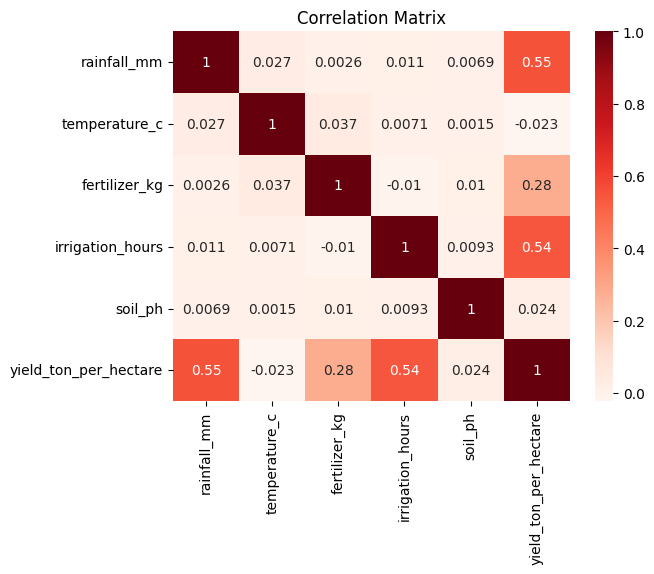

In [32]:
#Q9:Correlation Analysis
#Part 1:Correlation matrix for numerical features
numerical_df = df.select_dtypes(include=['number'])
a= numerical_df.corr()
print(a)

#Part 2: Heatmap
print()
sns.heatmap(numerical_df.corr(), cmap='Reds', annot=True)
plt.title('Correlation Matrix')

Q9,Part 3: Identify the top three features nost related with crop yield
The top three features are: rainfall_mm,irrigation_hours, fertilizer_kg

In [33]:
#Q10:Group_Based Analysis
#Calculate the average yield for:

#Each crop_type:
print(df.groupby('crop_type')['yield_ton_per_hectare'].mean())

#Each soil_type:
print(df.groupby('soil_type')['yield_ton_per_hectare'].mean())

crop_type
Cotton     4.607299
Maize      4.897143
Rice       5.494744
Soybean    5.173431
Wheat      4.989472
Name: yield_ton_per_hectare, dtype: float64
soil_type
Clay     5.134326
Loamy    5.366519
Sandy    4.588882
Name: yield_ton_per_hectare, dtype: float64


Q10 (Additional question)
Which crop and soil type have the highest average yield?
Ans: Rice and Loamy, crop and soil type respectively,have the highest average yield.

In [34]:
#Part C:Data Preparation
#Q11:Feature Encoding
#The dataset contains categorical variables.

#Identify the categorical columns.
categorical_columns = df.select_dtypes(include=['object'])
print(categorical_columns.columns,": are the categorical columns")

#Convert them into numerical form using One-Hot Encoding.
df_encoded = pd.get_dummies(df, columns=['crop_type', 'soil_type'])
print("\nCategorical columns encoded")

#Display the first five rows of the transformed dataset.
print("\nFirst five rows of the transformed dataset are:", df_encoded.head())

Index(['crop_type', 'soil_type'], dtype='object') : are the categorical columns

Categorical columns encoded

First five rows of the transformed dataset are:    rainfall_mm  temperature_c  fertilizer_kg  irrigation_hours  soil_ph  \
0        588.6           18.6          242.4               6.5      6.5   
1        772.8           34.6          247.2              10.0      6.5   
2        970.9           36.3          168.4               7.3      6.4   
3        611.7           19.0          121.7               3.7      6.0   
4        696.1           29.6          184.6               5.1      6.1   

   yield_ton_per_hectare  crop_type_Cotton  crop_type_Maize  crop_type_Rice  \
0                   5.92             False             True           False   
1                   6.24             False             True           False   
2                   4.77             False            False           False   
3                   4.04             False             True           False

In [35]:
#Q12:Feature Selection
#To seperate:

#INPUT FEATURE(X):
X = df_encoded.drop(columns=['yield_ton_per_hectare'])

#OUTPUT FEATURE(Y):
y = df_encoded['yield_ton_per_hectare']

Specify which column is being used as the target variable.
Target Variable: yield_ton_per_hectare This column is used as the output variable because the model is trained to predict the crop yield based on input features such as rainfall, temperature, fertilizer usage, crop type, and soil type.

In [41]:
#Part D: Machine Learning
#Q13. Train-Test Split
#Split the data set into:

#80% Training Data
#20% Testing Data
from sklearn.model_selection import train_test_split

x=df.drop(["soil_type","crop_type"], axis=1)
y=df["yield_ton_per_hectare"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

#Display the shape of:
#x_train
print("x_train shape:", X_train.shape)

#y_train
print("y_train shape:", y_train.shape)

#x_test
print("x_test shape:", X_test.shape)

#y_test
print("y_test shape:", y_test.shape)

x_train shape: (1200, 13)
y_train shape: (1200,)
x_test shape: (300, 13)
y_test shape: (300,)


In [43]:
#Q14: Linear Regression Model

#part 1: Train a linear regression model
from sklearn.linear_model import LinearRegression
X_reg = df.drop(["soil_type","crop_type"], axis=1)
y_reg = df["yield_ton_per_hectare"]

X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg, y_reg,
    test_size=0.2,
    random_state=42)

lr = LinearRegression()
lr.fit(X_train_reg, y_train_reg)

print("Linear Regression is Model Trained Successfully")

#part 2:Display the model coefficients and intercept.
print("Intercept:", lr.intercept_)
print("Coefficients:", lr.coef_)

#part 3:Which feature has the highest positive coefficient?
coefficients = pd.DataFrame({
    'Feature': X_train_reg.columns,
    'Coefficient': lr.coef_
})
positive_coeff = coefficients[coefficients['Coefficient'] > 0]
highest_positive = positive_coeff.loc[positive_coeff['Coefficient'].idxmax()]
print(highest_positive)


Linear Regression is Model Trained Successfully
Intercept: 1.5987211554602254e-14
Coefficients: [ 1.07311902e-18 -2.22044605e-16 -5.55111512e-17  2.77555756e-17
  2.47198095e-17  1.00000000e+00]
Feature        yield_ton_per_hectare
Coefficient                      1.0
Name: 5, dtype: object
